In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    precision_recall_curve,
    f1_score)

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import GridSearchCV, StratifiedKFold

import joblib, os, warnings
warnings.filterwarnings('ignore')

os.makedirs('tuned_models', exist_ok=True)

# Project Overview

 **Credit card default prediction system** - a classic binary classification problem in the financial industry. The goal is to predict whether a client will default on their next month's payment based on demographic and payment history data.

**Why this matters?**
 Banks and financial institutions use such models to assess credit risk, set credit limits, and make informed lending decisions. Accurately predicting defaults helps minimize financial losses while ensuring creditworthy customers aren't wrongly denied service.

The pipeline:
1. Exploratory Data Analysis - understanding the data
2. Preprocessing - cleaning, splitting, scaling, and handling class imbalance
3. Data Training - comparing 5 classification algorithms
4. Evaluation - selecting the best model using Accuracy, AUC, and F1-score

In [8]:
data = pd.read_csv('UCI_Credit_Card.csv', header=0) # header=0 means the first row is used as column names.
print("Shape:", data.shape)
print(data.head())

Shape: (30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0    

Dataset contains 30,000 client records with 25 features including demographic information (age, sex, education, marriage), credit limit, repayment history over 6 months, bill amounts, and payment amounts. The target variable is whether the client will default next month.

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

All features are numeric (integers/floats), which means no encoding is needed for categorical variables.

In [11]:
data.rename(columns={'default.payment.next.month': 'default'}, inplace=True) # Rename the target column for convenience
print(data.columns)

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='str')


The target column has been renamed from `default.payment.next.month` to simply `default` for clarity and easier referencing.

In [12]:
print(data.isnull().sum())

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64


No missing values were found in any column. This is a clean dataset that requires no imputation.

In [13]:
print("\n— Target Distribution —")
print(data['default'].value_counts())
print(data['default'].value_counts(normalize=True).mul(100).round(1))



— Target Distribution —
default
0    23364
1     6636
Name: count, dtype: int64
default
0    77.9
1    22.1
Name: proportion, dtype: float64


The dataset is imbalanced: approximately 78% of clients did not default (class 0) and only 22% did (class 1).

# Exploratory Data Analysis

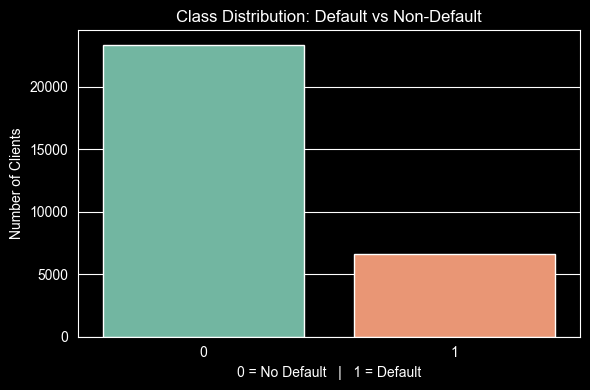

In [14]:
# Class distribution bar chart.
plt.figure(figsize=(6, 4))
sns.countplot(x='default', hue='default', data=data, palette='Set2', legend=False)
plt.title('Class Distribution: Default vs Non-Default')
plt.xlabel('0 = No Default   |   1 = Default')
plt.ylabel('Number of Clients')
plt.tight_layout()
plt.show()

Visual confirmation of class imbalance.

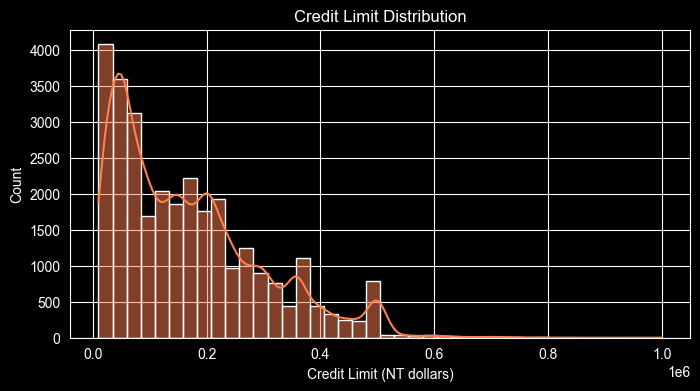

In [15]:
# Distribution of credit limits.
plt.figure(figsize=(8, 4))
sns.histplot(data['LIMIT_BAL'], bins=40, kde=True, color='coral')
plt.title('Credit Limit Distribution')
plt.xlabel('Credit Limit (NT dollars)')
plt.ylabel('Count')
plt.show()

Credit limits are right-skewed, which means that most clients have relatively low credit limits, with fewer clients holding very high limits.

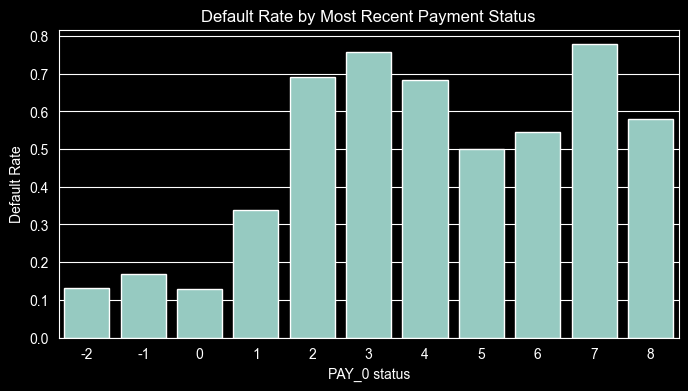

In [16]:
# Default rate grouped by PAY_0 (most recent repayment status).
# PAY_0 = -1  -> paid on time
# PAY_0 =  1  -> 1 month delay, 2 -> 2-month delay, etc.
plt.figure(figsize=(8, 4))
sns.barplot(x='PAY_0', y='default', data=data, errorbar=None)
plt.title('Default Rate by Most Recent Payment Status')
plt.xlabel('PAY_0 status')
plt.ylabel('Default Rate')
plt.show()

Higher delay codes -> higher default rate.

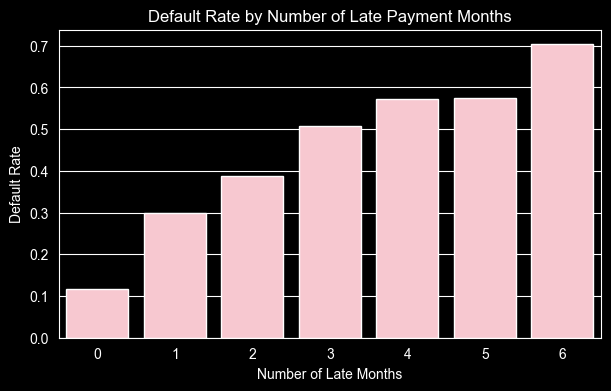

In [17]:
# Count how many of the 6 months the client was late (PAY > 0).
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
data['times_late'] = (data[pay_cols] > 0).sum(axis=1)
plt.figure(figsize=(7, 4))
sns.barplot(
    x='times_late',
    y='default',
    data=data,
    color='pink',
    ci=None
)
plt.title('Default Rate by Number of Late Payment Months')
plt.xlabel('Number of Late Months')
plt.ylabel('Default Rate')
plt.show()

Strong positive relationship: more late months -> higher default risk.


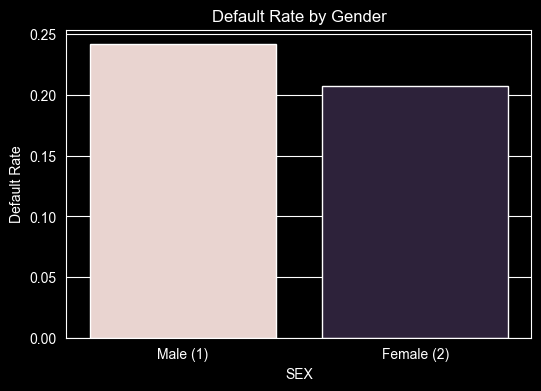

In [18]:
# Default rate by gender. SEX=1 ->  Male, SEX=2 -> Female.
plt.figure(figsize=(6, 4))
sns.barplot(x='SEX', y='default', data=data, errorbar=None, hue='SEX', legend=False)
plt.title('Default Rate by Gender')
plt.xticks([0, 1], ['Male (1)', 'Female (2)'])
plt.ylabel('Default Rate')
plt.show()

Male clients show a slightly higher default rate than female clients.

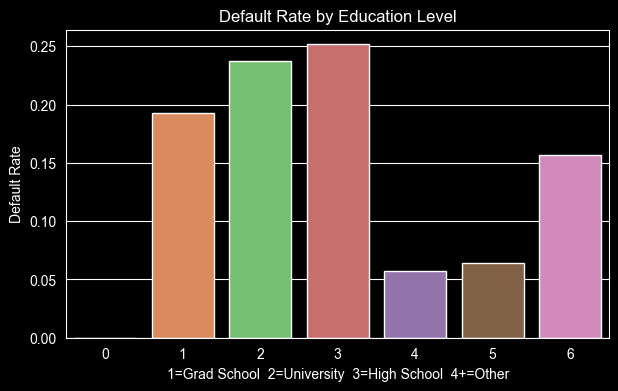

In [19]:
# Default rate by education level.
# 1=Graduate school  2=University  3=High school  4+=Other/Unknown
plt.figure(figsize=(7, 4))
sns.barplot(x='EDUCATION', y='default', data=data, palette = 'muted', errorbar=None, hue = 'EDUCATION', legend=False)
plt.title('Default Rate by Education Level')
plt.xlabel('1=Grad School  2=University  3=High School  4+=Other')
plt.ylabel('Default Rate')
plt.show()

Clients with graduate school education tend to have slightly lower default rates compared to those with a high school education or other.

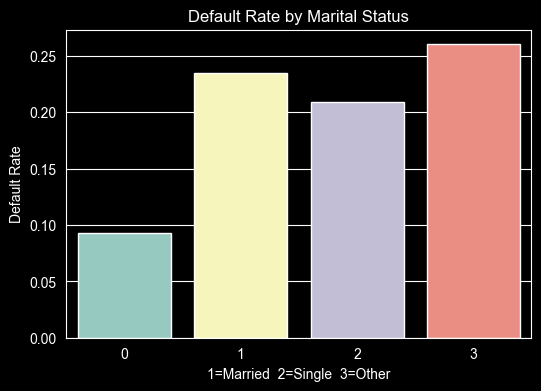

In [20]:
# Default rate by marital status.
# 1=Married  2=Single  3=Other
plt.figure(figsize=(6, 4))
sns.barplot(x='MARRIAGE', y='default', data=data, palette='Set3', errorbar=None, hue='MARRIAGE', legend=False)
plt.title('Default Rate by Marital Status')
plt.xlabel('1=Married  2=Single  3=Other')
plt.ylabel('Default Rate')
plt.show()

Marital status shows minor differences in default rates across groups, with single clients showing slightly higher default rates than married ones.

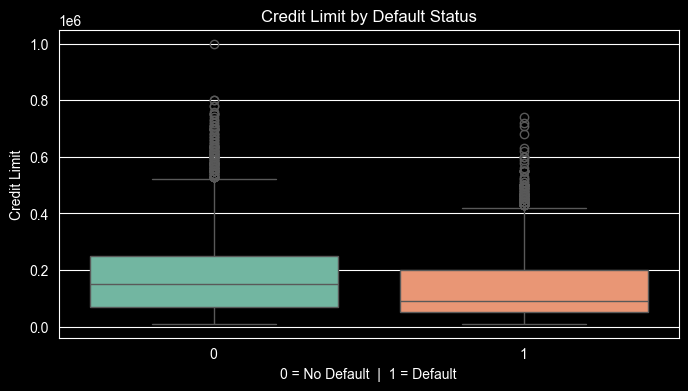

In [21]:
# Box plot: credit limit split by default status.
plt.figure(figsize=(8, 4))
sns.boxplot(x='default', y='LIMIT_BAL', data=data, palette = 'Set2', hue = 'default', legend = False)
plt.title('Default Rate by Default')
plt.xlabel('Default')
plt.title('Credit Limit by Default Status')
plt.xlabel('0 = No Default  |  1 = Default')
plt.ylabel('Credit Limit')
plt.show()

Clients who defaulted tend to have lower credit limits than those who did not.

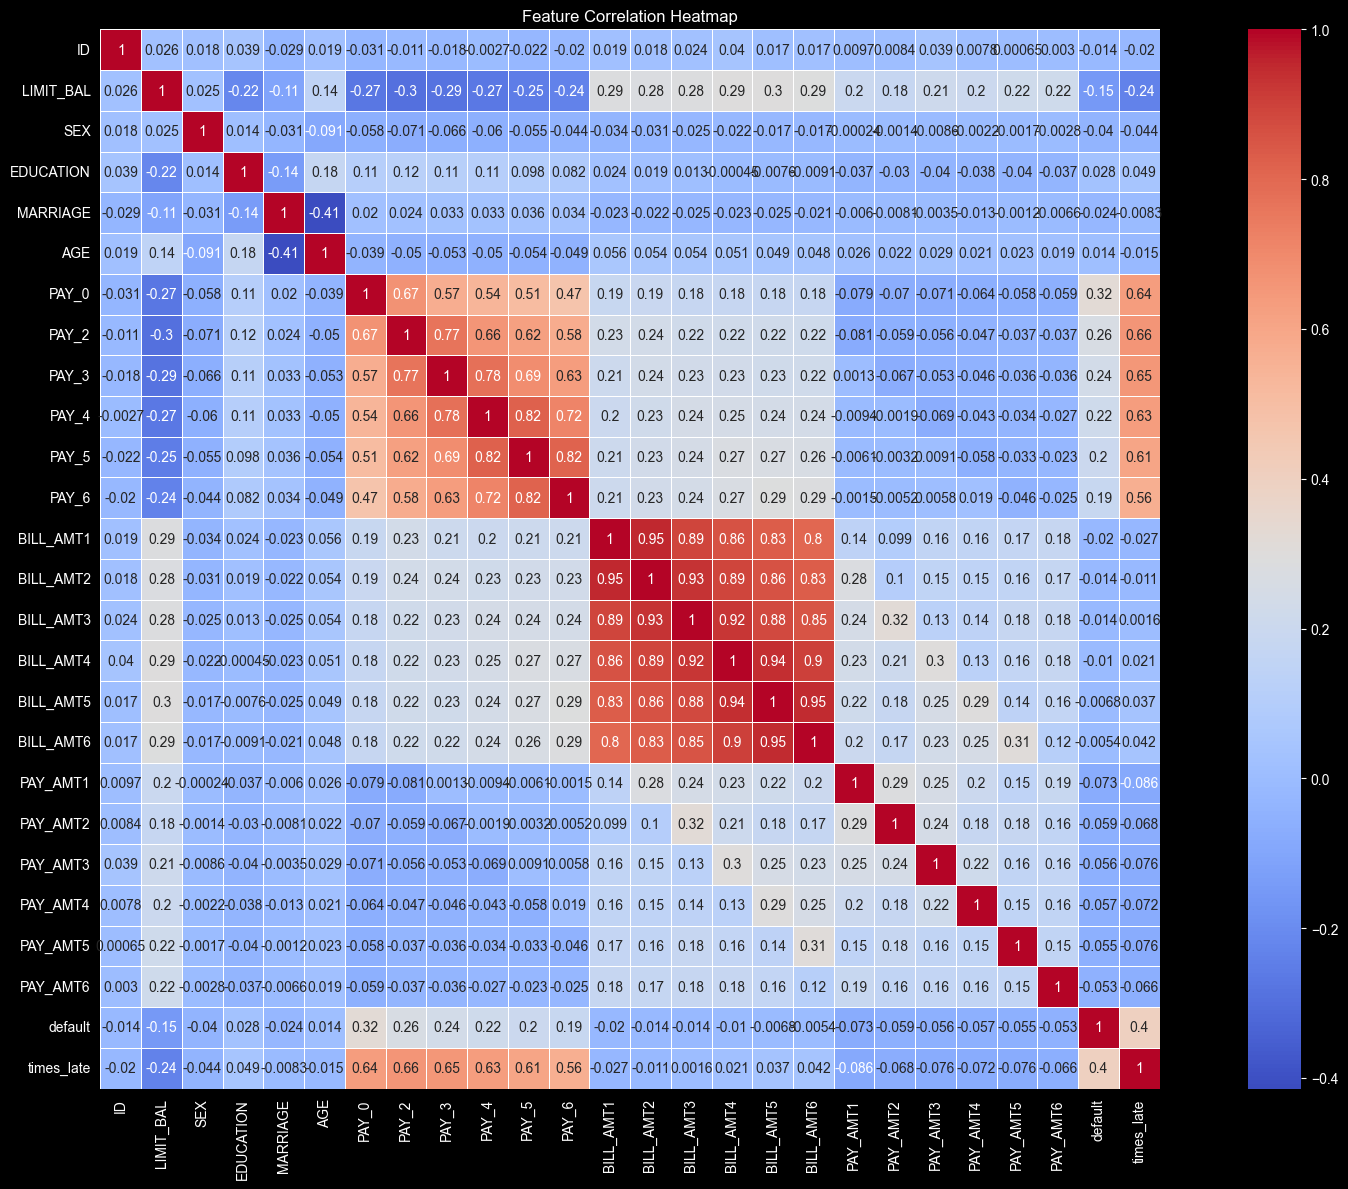

In [22]:
# Correlation heatmap for all numeric features.
plt.figure(figsize=(18, 12))
corr_matrix = data.corr()
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    linewidths=0.5,
    square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Key observations:

   • PAY_0–PAY_6 positively correlated with 'default' (strongest predictors)

   • BILL_AMT1–6 are highly inter-correlated -> redundant -> will be summarized

   • LIMIT_BAL negatively correlated with "default"


# Data Preprocessing

#### Feature Engineering

In [23]:
pay_cols     = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
bill_cols    = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

# Clean unusual category codes from the dataset.
data['EDUCATION'] = data['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
data['MARRIAGE'] = data['MARRIAGE'].replace({0: 3})

# Number of months the client was late (PAY > 0 means delayed payment)
data['times_late'] = (data[pay_cols] > 0).sum(axis=1)

# Average monthly bill compresses 6 correlated columns into one signal
data['avg_bill'] = data[bill_cols].mean(axis=1)

# Average payment amount over 6 months
data['avg_pay_amt'] = data[pay_amt_cols].mean(axis=1)

# Pay ratio: what fraction of the average bill did the client actually pay?
# Clipped at 99th percentile to remove extreme outliers.
data['pay_ratio'] = data['avg_pay_amt'] / (data['avg_bill'].abs() + 1)
data['pay_ratio'] = data['pay_ratio'].clip(upper=data['pay_ratio'].quantile(0.99))

# Drop original bill columns after creating summary features.
data.drop(columns=bill_cols, inplace=True)

# Client ID has no predictive value
data.drop(columns=['ID'], inplace=True)

print('New data shape:', data.shape)


New data shape: (30000, 22)


In [24]:
X = data.drop(columns=['default'])
# X = everything except the target column

y = data['default']
# y = only the target column

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Default rate: {y.mean():.2%}")

X shape: (30000, 21)
y shape: (30000,)
Default rate: 22.12%


#### Data splitting

In [25]:
# Split into Train (80%) / Validation (10%) / Test (10%).
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp)

print(f"\nTrain size:      {X_train.shape[0]} rows")
print(f"Validation size: {X_val.shape[0]} rows")
print(f"Test size:       {X_test.shape[0]} rows")


Train size:      24000 rows
Validation size: 3000 rows
Test size:       3000 rows


#### Feature Scaling

In [26]:
# StandardScaler: transforms each feature to mean=0, std=1.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train_scaled mean: {X_train_scaled.mean():.4f}")
print(f"X_train_scaled std: {X_train_scaled.std():.4f}")

X_train_scaled mean: -0.0000
X_train_scaled std: 1.0000


StandardScaler normalizes each feature to have mean ≈ 0 and standard deviation ≈ 1. This is critical for distance-based and gradient-based models. Without scaling, features with large ranges would dominate over smaller-range features. Tree-based models are scale-invariant, but scaling doesn't hurt them either.

In [27]:
print(f"\nBefore SMOTE:")
print(f"  No Default (0): {(y_train == 0).sum()}")
print(f"  Default    (1): {(y_train == 1).sum()}")

# SMOTE: Synthetic Minority Over-sampling Technique.
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE:")
print(f"  No Default (0): {(y_train_bal == 0).sum()}")
print(f"  Default    (1): {(y_train_bal == 1).sum()}")


Before SMOTE:
  No Default (0): 18691
  Default    (1): 5309

After SMOTE:
  No Default (0): 18691
  Default    (1): 18691


SMOTE has balanced the training set by generating synthetic samples of the minority class (defaulters) until both classes are equal. This prevents the model from being biased toward always predicting "no default."

# Data Training

In [28]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42),


    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
}

#### Comparison table of all models
Training all 6 models with default hyperparameters on the balanced training set
and evaluating both on the training and validation set. This gives us a starting benchmark before tuning.

In [29]:
# Training / Validation / Test Set Evaluation
base_train_results = {}
base_val_results = {}
base_test_results = {}

for model_name, model in models.items():

    model.fit(X_train_bal, y_train_bal)

    # Training set
    y_train_pred = model.predict(X_train_bal)
    y_train_proba = model.predict_proba(X_train_bal)[:, 1]

    base_train_results[model_name] = {
        'Accuracy':  accuracy_score(y_train_bal, y_train_pred),
        'AUC':       roc_auc_score(y_train_bal, y_train_proba),
        'F1':        f1_score(y_train_bal, y_train_pred),
        'Precision': precision_score(y_train_bal, y_train_pred),
        'Recall':    recall_score(y_train_bal, y_train_pred),
    }

    # Validation set
    y_val_pred = model.predict(X_val_scaled)
    y_val_proba = model.predict_proba(X_val_scaled)[:, 1]

    base_val_results[model_name] = {
        'Accuracy':  accuracy_score(y_val, y_val_pred),
        'AUC':       roc_auc_score(y_val, y_val_proba),
        'F1':        f1_score(y_val, y_val_pred),
        'Precision': precision_score(y_val, y_val_pred),
        'Recall':    recall_score(y_val, y_val_pred),
    }

base_train_df = pd.DataFrame(base_train_results).T.sort_values('F1', ascending=False).round(4)
base_val_df = pd.DataFrame(base_val_results).T.sort_values('F1', ascending=False).round(4)

print("Training Set Scores:")
print(base_train_df)
print(f"\nBest model by F1 on training set: {base_train_df['F1'].idxmax()}")

print("\nValidation Set Scores:")
print(base_val_df)
print(f"\nBest model by F1 on validation set: {base_val_df['F1'].idxmax()}")

Training Set Scores:
                     Accuracy     AUC      F1  Precision  Recall
Random Forest          0.9997  1.0000  0.9997     0.9996  0.9997
XGBoost                0.8681  0.9409  0.8612     0.9093  0.8178
Gradient Boosting      0.8113  0.8855  0.7988     0.8556  0.7490
AdaBoost               0.7122  0.7790  0.6832     0.7598  0.6206
Logistic Regression    0.7024  0.7603  0.6655     0.7597  0.5921

Best model by F1 on training set: Random Forest

Validation Set Scores:
                     Accuracy     AUC      F1  Precision  Recall
Gradient Boosting      0.8027  0.7843  0.5474     0.5559  0.5392
AdaBoost               0.7690  0.7759  0.5365     0.4826  0.6039
Logistic Regression    0.7643  0.7597  0.5226     0.4737  0.5828
XGBoost                0.8040  0.7683  0.5132     0.5699  0.4669
Random Forest          0.7917  0.7510  0.4947     0.5340  0.4608

Best model by F1 on validation set: Gradient Boosting


## Hyperparameter tuning

In [30]:
# Folder for saving tuned models
os.makedirs('tuned_models', exist_ok=True)

# 5-fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def tune_and_evaluate(name, model, param_grid):
    print(f"Tuning: {name}")

    search = GridSearchCV(
        model,
        param_grid,
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        verbose=0
    )

    search.fit(X_train_bal, y_train_bal)

    best_model = search.best_estimator_

    # Validation predictions
    preds = best_model.predict(X_val_scaled)
    proba = best_model.predict_proba(X_val_scaled)[:, 1]

    # Print results
    print("Best parameters:", search.best_params_)

    print("Accuracy:",  round(accuracy_score(y_val, preds), 4))
    print("Precision:", round(precision_score(y_val, preds), 4))
    print("Recall:",    round(recall_score(y_val, preds), 4))
    print("F1-score:",  round(f1_score(y_val, preds), 4))
    print("ROC-AUC:",   round(roc_auc_score(y_val, proba), 4))

    print("\nClassification report:")
    print(classification_report(
        y_val,
        preds,
        target_names=['No Default', 'Default']
    ))

    print("Confusion matrix:")
    cm = confusion_matrix(y_val, preds)
    print(cm)

    # Confusion matrix graphic
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Default', 'Default']
    )

    disp.plot(values_format='d')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    # Save only model
    file_name = name.lower().replace(" ", "_")
    joblib.dump(
        {'model': best_model},
        f'tuned_models/{file_name}.pkl'
    )

    return best_model, preds, proba

#### Logistic Regression

Tuning: Logistic Regression
Best parameters: {'C': 0.001, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy: 0.7467
Precision: 0.4464
Recall: 0.6024
F1-score: 0.5128
ROC-AUC: 0.7441

Classification report:
              precision    recall  f1-score   support

  No Default       0.87      0.79      0.83      2336
     Default       0.45      0.60      0.51       664

    accuracy                           0.75      3000
   macro avg       0.66      0.70      0.67      3000
weighted avg       0.78      0.75      0.76      3000

Confusion matrix:
[[1840  496]
 [ 264  400]]


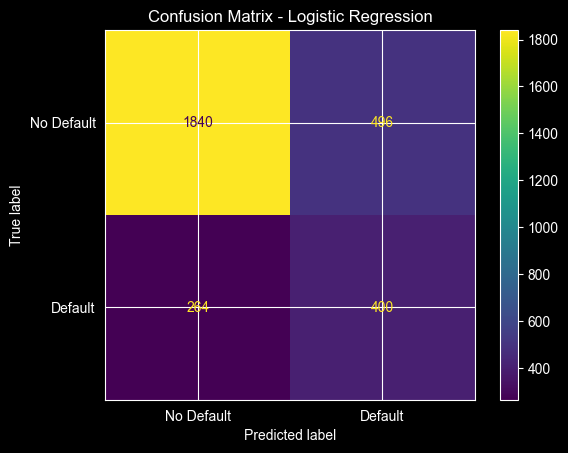

In [33]:
lr_best, lr_preds, lr_proba = tune_and_evaluate(
    'Logistic Regression',
    LogisticRegression(random_state=42, max_iter=1000),
    {
        'penalty':  ['l1', 'l2'], # C controls regularization strength, penalty selects l1 or l2
        'C':        [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10],
        'solver':   ['liblinear', 'saga'],
    }
)

#### Random Forest

Tuning: Random Forest
Best parameters: {'max_depth': 7, 'max_features': 0.5, 'max_samples': 0.9, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Accuracy: 0.775
Precision: 0.4932
Recall: 0.6039
F1-score: 0.543
ROC-AUC: 0.784

Classification report:
              precision    recall  f1-score   support

  No Default       0.88      0.82      0.85      2336
     Default       0.49      0.60      0.54       664

    accuracy                           0.78      3000
   macro avg       0.69      0.71      0.70      3000
weighted avg       0.79      0.78      0.78      3000

Confusion matrix:
[[1924  412]
 [ 263  401]]


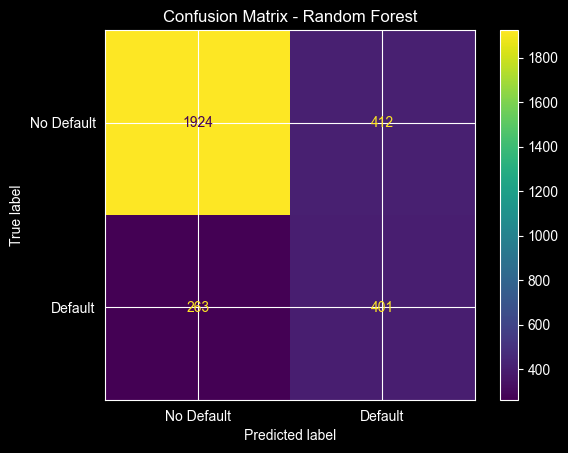

In [34]:
rf_best, rf_preds, rf_proba = tune_and_evaluate(
    'Random Forest',
    RandomForestClassifier(random_state=42),
    {
        'n_estimators':      [100, 200],    # n_estimators = number of trees,
        'max_depth':         [3, 5, 7],     # max_depth limits overfitting
        'min_samples_split': [10, 20],
        'min_samples_leaf':  [4, 8],
        'max_features':      ['sqrt', 0.5],
        'max_samples':       [0.7, 0.8, 0.9],
    }
)

#### Gradient Boosting

Tuning: Gradient Boosting
Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 8, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.8073
Precision: 0.586
Recall: 0.4413
F1-score: 0.5034
ROC-AUC: 0.7766

Classification report:
              precision    recall  f1-score   support

  No Default       0.85      0.91      0.88      2336
     Default       0.59      0.44      0.50       664

    accuracy                           0.81      3000
   macro avg       0.72      0.68      0.69      3000
weighted avg       0.79      0.81      0.80      3000

Confusion matrix:
[[2129  207]
 [ 371  293]]


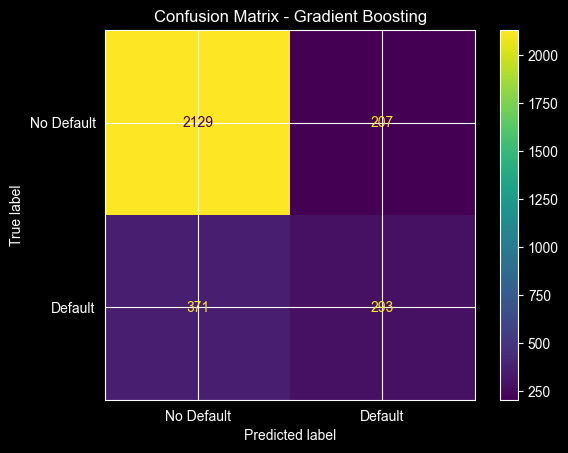

In [37]:
gb_best, gb_preds, gb_proba = tune_and_evaluate(
    'Gradient Boosting',
    GradientBoostingClassifier(random_state=42),
    {
        'n_estimators':  [100, 200],
        'max_depth':     [2, 3, 4],
        'learning_rate': [0.01, 0.05, 0.1],  # learning_rate controls each tree's contribution,
        'subsample':     [0.6, 0.7, 0.8],    #subsample adds randomness
        'min_samples_leaf': [4, 8, 16],
    }
)

#### XGBoost

Tuning: XGBoost
Best parameters: {'colsample_bytree': 0.8, 'gamma': 0.5, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 1.0, 'subsample': 0.8}
Accuracy: 0.8057
Precision: 0.5783
Recall: 0.4503
F1-score: 0.5064
ROC-AUC: 0.766

Classification report:
              precision    recall  f1-score   support

  No Default       0.85      0.91      0.88      2336
     Default       0.58      0.45      0.51       664

    accuracy                           0.81      3000
   macro avg       0.72      0.68      0.69      3000
weighted avg       0.79      0.81      0.80      3000

Confusion matrix:
[[2118  218]
 [ 365  299]]


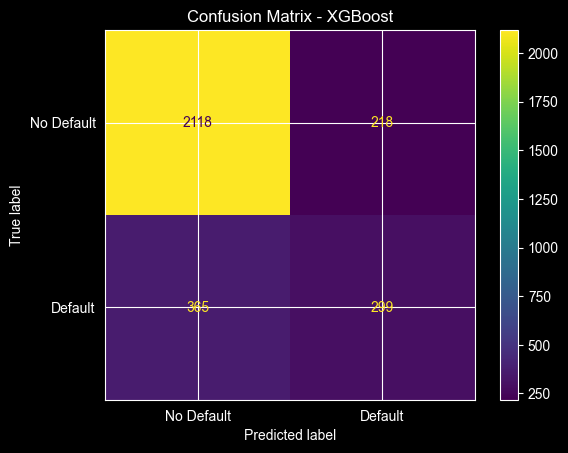

In [38]:
xgb_best, xgb_preds, xgb_proba = tune_and_evaluate(
    'XGBoost',
    XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    {
        'n_estimators':     [100, 200],
        'max_depth':        [3, 4, 5],
        'learning_rate':    [0.01, 0.05, 0.1],
        'subsample':        [0.6, 0.7, 0.8],
        'colsample_bytree': [0.6, 0.7, 0.8],
        'gamma':            [0.1, 0.3, 0.5, 1.0],  # gamma, reg_alpha, reg_lambda control regularization and tree growth
        'reg_alpha':        [0.1, 0.5, 1.0],
        'reg_lambda':       [1.0, 2.0, 5.0],
        'min_child_weight': [3, 5, 10],
    }
)

#### AdaBoost

Tuning: AdaBoost
Best parameters: {'learning_rate': 0.5, 'n_estimators': 200}
Accuracy: 0.7677
Precision: 0.4802
Recall: 0.6024
F1-score: 0.5344
ROC-AUC: 0.779

Classification report:
              precision    recall  f1-score   support

  No Default       0.88      0.81      0.85      2336
     Default       0.48      0.60      0.53       664

    accuracy                           0.77      3000
   macro avg       0.68      0.71      0.69      3000
weighted avg       0.79      0.77      0.78      3000

Confusion matrix:
[[1903  433]
 [ 264  400]]


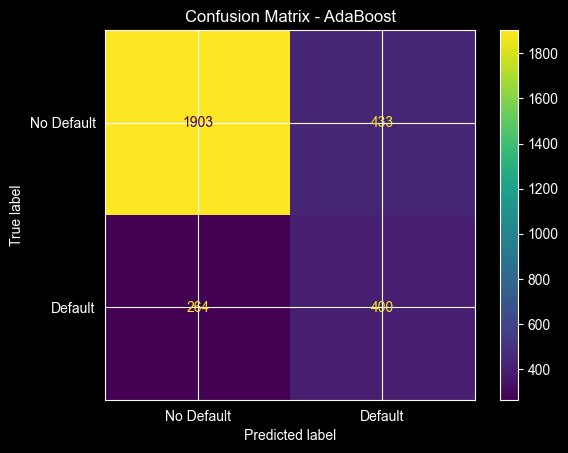

In [35]:
ada_best, ada_preds, ada_proba = tune_and_evaluate(
    'AdaBoost',
    AdaBoostClassifier(random_state=42),
    {
        'n_estimators':  [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.5],   # learning_rate and n_estimators balance speed vs accuracy
    }
)

### Final Comparison Table

In [40]:
tuned_results_summary = {}

tuned_models_map = {
    'Logistic Regression':  (lr_best,  lr_preds,  lr_proba),
    'Random Forest':        (rf_best,  rf_preds,  rf_proba),
    'Gradient Boosting':    (gb_best,  gb_preds,  gb_proba),
    'XGBoost':              (xgb_best, xgb_preds, xgb_proba),
    'AdaBoost':             (ada_best, ada_preds, ada_proba),
}

for model_name, (model, preds, proba) in tuned_models_map.items():
    tuned_results_summary[model_name] = {
        'Accuracy':  accuracy_score(y_val, preds),
        'AUC':       roc_auc_score(y_val, proba),
        'F1':        f1_score(y_val, preds),
        'Precision': precision_score(y_val, preds),
        'Recall':    recall_score(y_val, preds),
    }

tuned_df = pd.DataFrame(tuned_results_summary).T.sort_values('F1', ascending=False).round(4)
print(tuned_df)

                     Accuracy     AUC      F1  Precision  Recall
Random Forest          0.7750  0.7840  0.5430     0.4932  0.6039
AdaBoost               0.7677  0.7790  0.5344     0.4802  0.6024
Logistic Regression    0.7467  0.7441  0.5128     0.4464  0.6024
XGBoost                0.8057  0.7660  0.5064     0.5783  0.4503
Gradient Boosting      0.8073  0.7766  0.5034     0.5860  0.4413


In [41]:
# Training / Validation / Test Set Evaluation - Tuned Models
tuned_train_results = {}
tuned_val_results = {}
tuned_test_results = {}

for model_name in tuned_df.index:
    file_name = model_name.lower().replace(" ", "_")
    saved = joblib.load(f'tuned_models/{file_name}.pkl')
    model = saved['model']

    # Training set
    y_train_pred = model.predict(X_train_bal)
    y_train_proba = model.predict_proba(X_train_bal)[:, 1]

    tuned_train_results[model_name] = {
        'Accuracy':  accuracy_score(y_train_bal, y_train_pred),
        'AUC':       roc_auc_score(y_train_bal, y_train_proba),
        'F1':        f1_score(y_train_bal, y_train_pred),
        'Precision': precision_score(y_train_bal, y_train_pred),
        'Recall':    recall_score(y_train_bal, y_train_pred),
    }

    # Validation set
    y_val_pred = model.predict(X_val_scaled)
    y_val_proba = model.predict_proba(X_val_scaled)[:, 1]

    tuned_val_results[model_name] = {
        'Accuracy':  accuracy_score(y_val, y_val_pred),
        'AUC':       roc_auc_score(y_val, y_val_proba),
        'F1':        f1_score(y_val, y_val_pred),
        'Precision': precision_score(y_val, y_val_pred),
        'Recall':    recall_score(y_val, y_val_pred),
    }

    # Test set
    y_test_pred = model.predict(X_test_scaled)
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

    tuned_test_results[model_name] = {
        'Accuracy':  accuracy_score(y_test, y_test_pred),
        'AUC':       roc_auc_score(y_test, y_test_proba),
        'F1':        f1_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall':    recall_score(y_test, y_test_pred),
    }

tuned_train_df = pd.DataFrame(tuned_train_results).T.sort_values('F1', ascending=False).round(4)
tuned_val_df = pd.DataFrame(tuned_val_results).T.sort_values('F1', ascending=False).round(4)
tuned_test_df = pd.DataFrame(tuned_test_results).T.sort_values('F1', ascending=False).round(4)

print("Training Set Scores - Tuned Models:")
print(tuned_train_df)
print(f"\nBest tuned model by F1 on training set: {tuned_train_df['F1'].idxmax()}")

print("\nValidation Set Scores - Tuned Models:")
print(tuned_val_df)
print(f"\nBest tuned model by F1 on validation set: {tuned_val_df['F1'].idxmax()}")

print("\nTest Set Scores - Tuned Models:")
print(tuned_test_df)
print(f"\nBest tuned model by F1 on test set: {tuned_test_df['F1'].idxmax()}")

Training Set Scores - Tuned Models:
                     Accuracy     AUC      F1  Precision  Recall
Gradient Boosting      0.8717  0.9384  0.8644     0.9166  0.8179
XGBoost                0.8706  0.9433  0.8634     0.9147  0.8175
Random Forest          0.7651  0.8478  0.7493     0.8033  0.7022
AdaBoost               0.7305  0.8123  0.7078     0.7730  0.6528
Logistic Regression    0.7029  0.7450  0.6760     0.7433  0.6199

Best tuned model by F1 on training set: Gradient Boosting

Validation Set Scores - Tuned Models:
                     Accuracy     AUC      F1  Precision  Recall
Random Forest          0.7750  0.7840  0.5430     0.4932  0.6039
AdaBoost               0.7677  0.7790  0.5344     0.4802  0.6024
Logistic Regression    0.7467  0.7441  0.5128     0.4464  0.6024
XGBoost                0.8057  0.7660  0.5064     0.5783  0.4503
Gradient Boosting      0.8073  0.7766  0.5034     0.5860  0.4413

Best tuned model by F1 on validation set: Random Forest

Test Set Scores - Tuned Mode

# Final Evaluation on Test Set

Now that all models are tuned and compared on the validation set, let's evaluate the best model on the held-out test set. This gives us an unbiased estimate of real-world performance.

Best Tuned Model: Random Forest

Final Test Set Results:
Accuracy: 0.7557
AUC: 0.7562
F1: 0.5136
Precision: 0.4585
Recall: 0.5837

Classification Report:
              precision    recall  f1-score   support

  No Default       0.87      0.80      0.84      2337
     Default       0.46      0.58      0.51       663

    accuracy                           0.76      3000
   macro avg       0.67      0.69      0.68      3000
weighted avg       0.78      0.76      0.77      3000



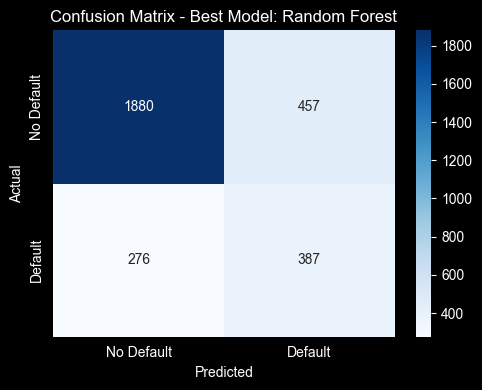

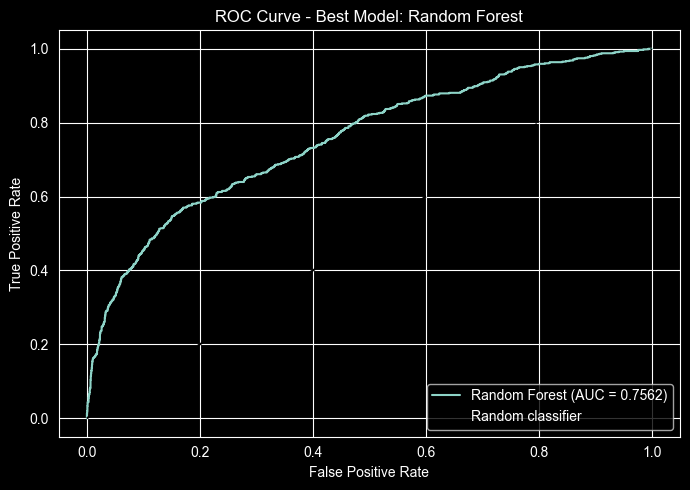

In [42]:
# Final Evaluation on Test Set - Best Tuned Model

best_model_name = tuned_test_df['F1'].idxmax()

file_name = best_model_name.lower().replace(" ", "_")
saved = joblib.load(f'tuned_models/{file_name}.pkl')
best_model = saved['model']

print(f"Best Tuned Model: {best_model_name}")

# Test predictions
y_test_pred = best_model.predict(X_test_scaled)
y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("\nFinal Test Set Results:")
print("Accuracy:",  round(accuracy_score(y_test, y_test_pred), 4))
print("AUC:",       round(roc_auc_score(y_test, y_test_proba), 4))
print("F1:",        round(f1_score(y_test, y_test_pred), 4))
print("Precision:", round(precision_score(y_test, y_test_pred), 4))
print("Recall:",    round(recall_score(y_test, y_test_pred), 4))

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=['No Default', 'Default']
))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Default', 'Default'],
    yticklabels=['No Default', 'Default']
)

plt.title(f'Confusion Matrix - Best Model: {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - Best Model: {best_model_name}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

This project built and evaluated a credit card default prediction system on 30,000 client records using a full end-to-end machine learning pipeline.

## Pipeline Summary
- **EDA** revealed a 22% default rate and a strong positive relationship between late payment months and default risk.
- **Preprocessing** included StandardScaler normalization and SMOTE oversampling to address class imbalance.
- **Baseline training** compared 5 classifiers with default hyperparameters.
- **Hyperparameter tuning** via GridSearchCV with 5-fold Stratified cross-validation improved generalization across all models.
- **Best model on test set: Random Forest** (after tuning) — Accuracy: 0.7557 | AUC: 0.7562 | F1: 0.5136 | Precision: 0.4585 | Recall: 0.5837.